# 07 Real Portfolio — Stop-Loss / Re-entry Analysis

Applies the stop-loss and re-entry simulation from notebook 04 to **every position
in your real Deutsche Bank portfolio**, sourcing cost-basis data directly from the
broker PDF and fetching live market prices via Yahoo Finance.

**What this notebook does:**
1. Parses the DB PDF to extract real holdings (ISIN, shares, EUR cost basis per share)
2. Fetches current EUR prices for each position
3. For every position runs the full stop × bear-scenario cross-product
4. Shows a **portfolio ranking table** — which positions benefit most from a stop
5. Shows **per-position heatmaps** (same format as notebook 04) using real numbers

**Key question answered:** Given my actual gains and position sizes today,
which holdings are the best candidates for stop-loss protection, and at what trigger level?

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from pdf_parser import parse_db_pdf
from portfolio_sim import (
    ECBProvider,
    YahooPriceProvider,
    fetch_current_prices,
    initialize_lots_from_holdings,
)
from tax_risk_sim import (
    build_bear_recovery_cases,
    build_bear_recovery_table,
    build_stop_benchmark,
    compare_stop_reentry_vs_hold,
    sell_today_baseline,
)

pd.options.display.float_format = "{:,.2f}".format

## Inputs

Set the `DB_PDF_PATH` environment variable before starting JupyterLab:

```bash
export DB_PDF_PATH=data/private/report.pdf
docker compose up
```

The notebook reads `DB_PDF_PATH` at runtime — no filename is hardcoded in the
notebook source. `data/private/ticker_map.json` is used for the ISIN → Yahoo
ticker map; edit it to match your holdings.

All other parameters (tax rate, stop levels, bear scenarios) use the same
defaults as notebook 04.

In [ ]:
import json
import os

# ── File paths (read from env — never hardcode data/private/ filenames) ───────
_pdf_env = os.environ.get("DB_PDF_PATH")
if not _pdf_env:
    raise EnvironmentError(
        "Set DB_PDF_PATH to your Deutsche Bank PDF report path.\n"
        "Example:  export DB_PDF_PATH=data/private/report.pdf"
    )
PDF_PATH        = Path(_pdf_env) if Path(_pdf_env).is_absolute() else PROJECT_ROOT / _pdf_env
TICKER_MAP_PATH = PROJECT_ROOT / "data/private/ticker_map.json"
REPORTING_DATE  = "2026-06-06"   # ISO date used for price lookup

# ── Tax & simulation parameters (match notebook 04 defaults) ─────────────────
CAPITAL_GAINS_TAX_RATE      = 0.26375   # German Abgeltungsteuer + Soli
STOP_LOSS_DROPS             = np.array([0.05, 0.10, 0.15, 0.20, 0.25, 0.30])
REENTRY_SLIPPAGE            = 0.05      # 5% above the bear low
TRANSACTION_COST_RATE       = 0.001     # 0.1% per leg
ALLOW_FRACTIONAL_SHARES     = False

# ── Bear scenario grid ────────────────────────────────────────────────────────
BEAR_START              = -0.05
BEAR_END                = -0.60
BEAR_STEP               = -0.05        # 5% steps → 12 columns (keeps heatmaps readable)
BEAR_RECOVERY_MULT      = 1.50
BEAR_MIN_RECOVERY       = 0.10
BEAR_MAX_RECOVERY       = 1.50
BEAR_BASE_PROB          = 0.70
BEAR_MIN_PROB           = 0.10

# ── Load ticker map ───────────────────────────────────────────────────────────
with open(TICKER_MAP_PATH) as f:
    _raw = json.load(f)
TICKER_MAP = {k: v for k, v in _raw.items() if not k.startswith("_")}
print(f"Ticker map loaded: {len(TICKER_MAP)} ISINs")

## Step 1 — Parse PDF and seed lot ledger

In [3]:
_tx_df, hld_df = parse_db_pdf(PDF_PATH)
lots_df = initialize_lots_from_holdings(hld_df)

print(f"Holdings parsed : {len(hld_df)} positions")
print(f"Lots seeded     : {len(lots_df)} lots")
hld_df[["isin", "wkn", "asset_name", "quantity", "cost_basis_eur", "market_value"]]

Holdings parsed : 14 positions
Lots seeded     : 14 lots


,isin,wkn,asset_name,quantity,cost_basis_eur,market_value
0,NL0000226223,893438,"STMICROELECTRONICSN.V.AANDELENEO 1,04",20.00,26.85,"1,222.60"
1,US0258161092,850226,"AMERICANEXPRESSCO.RG.SH.DL-,20",50.00,204.82,"13,481.87"
2,US1912161007,850663,"COCA-COLACO.,THEREGISTEREDSHARES DL-,25",100.00,54.28,"6,898.47"
3,US4581401001,855681,"INTELCORP.REGISTEREDSHARESDL-,001",100.00,43.94,"8,591.84"
4,US0378331005,865985,APPLEINC.REGISTEREDSHARESO.N.,85.00,140.24,"22,690.47"
5,US5949181045,870747,"MICROSOFTCORP.RG.SH.DL-,00000625",35.00,302.50,"12,661.35"
6,US0231351067,906866,"AMAZON.COMINC.REGISTEREDSHARES DL-,01",30.00,129.54,"6,405.99"
7,US67066G1040,918422,"NVIDIACORP.REGISTEREDSHARESDL-,001",205.00,63.39,"36,498.73"
8,DE000A0F5UF5,A0F5UF,ISHARE.NASDAQ-100UCITSETFDE INHABER-ANT.,340.00,203.25,"84,218.00"
9,US92826C8394,A0NC7B,"VISAINC.REG.SHARESCLASSADL-,0001",20.00,237.52,"5,616.85"


## Step 2 — Fetch live prices

In [4]:
price_provider = YahooPriceProvider(
    isin_to_ticker=TICKER_MAP,
    fx_provider=ECBProvider(),
)

isins = lots_df["isin"].tolist()
PRICES_EUR = fetch_current_prices(isins, price_provider, REPORTING_DATE)

print(f"Prices fetched: {len(PRICES_EUR)}/{len(isins)} ISINs")
price_series = pd.Series(PRICES_EUR, name="price_eur").sort_index()
price_series

Prices fetched: 14/14 ISINs


DE000A0F5UF5   249.85
IE00BTJRMP35    79.15
LU0274209740    99.96
NL0000226223    60.76
US02079K3059   316.61
US0231351067   211.37
US0258161092   266.89
US0378331005   264.04
US1912161007    68.28
US30303M1027   509.45
US4581401001    85.20
US5949181045   357.96
US67066G1040   176.20
US92826C8394   277.98
Name: price_eur, dtype: float64

## Step 3 — Portfolio snapshot

Market value, unrealised gain, and gain % for every position at today's prices.

In [5]:
snapshot_rows = []
for _, lot in lots_df.iterrows():
    isin   = lot["isin"]
    shares = float(lot["remaining_shares"])
    basis  = float(lot["lot_price_eur"])
    price  = PRICES_EUR.get(isin)
    if price is None:
        continue
    mv          = shares * price
    cost        = shares * basis
    unr_gain    = mv - cost
    unr_gain_pct = (price - basis) / basis if basis > 0 else 0.0
    name = hld_df.loc[hld_df["isin"] == isin, "asset_name"].iloc[0]
    snapshot_rows.append({
        "isin": isin,
        "name": name[:28],
        "ticker": TICKER_MAP.get(isin, ""),
        "shares": shares,
        "basis_eur": basis,
        "price_eur": price,
        "market_value_eur": mv,
        "unrealised_gain_eur": unr_gain,
        "unrealised_gain_pct": unr_gain_pct,
    })

snap_df = pd.DataFrame(snapshot_rows).sort_values("market_value_eur", ascending=False)

total_mv   = snap_df["market_value_eur"].sum()
total_gain = snap_df["unrealised_gain_eur"].sum()
print(f"Total market value  : EUR {total_mv:>12,.0f}")
print(f"Total unrealised gain: EUR {total_gain:>11,.0f}  ({total_gain/total_mv*100:.1f}% of MV)")
print()

snap_df.style \
    .format({
        "shares": "{:,.1f}",
        "basis_eur": "€{:,.2f}",
        "price_eur": "€{:,.2f}",
        "market_value_eur": "€{:,.0f}",
        "unrealised_gain_eur": "€{:,.0f}",
        "unrealised_gain_pct": "{:+.1%}",
    }) \
    .background_gradient(subset=["unrealised_gain_pct"], cmap="RdYlGn", vmin=-0.5, vmax=2.0)

Total market value  : EUR      XXX,XXX
Total unrealised gain: EUR      71,090  (31.6% of MV)



,isin,name,ticker,shares,basis_eur,price_eur,market_value_eur,unrealised_gain_eur,unrealised_gain_pct
8,DE000A0F5UF5,ISHARE.NASDAQ-100UCITSETFDE,EXXT.DE,340.0,€203.25,€249.85,"€84,949","€15,844",+22.9%
7,US67066G1040,NVIDIACORP.REGISTEREDSHARESD,NVDA,205.0,€63.39,€176.20,"€36,122","€23,127",+178.0%
4,US0378331005,APPLEINC.REGISTEREDSHARESO.N,AAPL,85.0,€140.24,€264.04,"€22,443","€10,523",+88.3%
1,US0258161092,"AMERICANEXPRESSCO.RG.SH.DL-,",AXP,50.0,€204.82,€266.89,"€13,345","€3,103",+30.3%
5,US5949181045,"MICROSOFTCORP.RG.SH.DL-,0000",MSFT,35.0,€302.50,€357.96,"€12,529","€1,941",+18.3%
10,US02079K3059,ALPHABETINC.REG.SHSCAP.STKCL,GOOGL,35.0,€143.26,€316.61,"€11,081","€6,067",+121.0%
11,US30303M1027,METAPLATFORMSINC.REG.SH.CL.A,META,20.0,€460.01,€509.45,"€10,189",€989,+10.7%
3,US4581401001,INTELCORP.REGISTEREDSHARESDL,INTC,100.0,€43.94,€85.20,"€8,520","€4,126",+93.9%
2,US1912161007,"COCA-COLACO.,THEREGISTEREDSH",KO,100.0,€54.28,€68.28,"€6,828","€1,400",+25.8%
6,US0231351067,AMAZON.COMINC.REGISTEREDSHAR,AMZN,30.0,€129.54,€211.37,"€6,341","€2,455",+63.2%


## Step 4 — Build shared bear scenarios

One set of bear cases is reused across all positions (the shape of each scenario
is fixed; the absolute prices differ per position).

In [6]:
bear_cases = build_bear_recovery_cases(
    start=BEAR_START,
    end=BEAR_END,
    step=BEAR_STEP,
    recovery_multiplier=BEAR_RECOVERY_MULT,
    min_recovery_return=BEAR_MIN_RECOVERY,
    max_recovery_return=BEAR_MAX_RECOVERY,
    base_recovery_probability=BEAR_BASE_PROB,
    min_recovery_probability=BEAR_MIN_PROB,
)
bear_case_order = bear_cases["case"].tolist()
print(f"{len(bear_cases)} bear scenarios: {bear_cases['case'].iloc[0]} → {bear_cases['case'].iloc[-1]}")
bear_cases

12 bear scenarios: Bear -5% → Bear -60%


,case,drawdown,recovery_return_from_low,recovery_probability
0,Bear -5%,-0.05,0.10,0.65
1,Bear -10%,-0.10,0.15,0.60
2,Bear -15%,-0.15,0.22,0.55
3,Bear -20%,-0.20,0.30,0.50
4,Bear -25%,-0.25,0.38,0.45
5,Bear -30%,-0.30,0.45,0.40
6,Bear -35%,-0.35,0.52,0.35
7,Bear -40%,-0.40,0.60,0.30
8,Bear -45%,-0.45,0.68,0.25
9,Bear -50%,-0.50,0.75,0.20


## Step 5 — Run stop-loss simulation for every position

In [7]:
results = {}   # isin → {comparison_df, stop_benchmark, bear_recovery_df, baseline, meta}

for _, lot in lots_df.iterrows():
    isin   = lot["isin"]
    shares = float(lot["remaining_shares"])
    basis  = float(lot["lot_price_eur"])
    price  = PRICES_EUR.get(isin)
    if price is None:
        continue

    baseline       = sell_today_baseline(shares, price, basis, CAPITAL_GAINS_TAX_RATE)
    stop_bench     = build_stop_benchmark(STOP_LOSS_DROPS, shares, price, basis, CAPITAL_GAINS_TAX_RATE)
    bear_rec_df    = build_bear_recovery_table(bear_cases, shares, price, basis, CAPITAL_GAINS_TAX_RATE)
    comparison_df  = compare_stop_reentry_vs_hold(
        stop_bench, bear_rec_df, shares, basis, CAPITAL_GAINS_TAX_RATE,
        reentry_slippage_from_bear_low=REENTRY_SLIPPAGE,
        transaction_cost_rate=TRANSACTION_COST_RATE,
        allow_fractional_reentry_shares=ALLOW_FRACTIONAL_SHARES,
    )

    results[isin] = {
        "comparison": comparison_df,
        "stop_benchmark": stop_bench,
        "bear_recovery": bear_rec_df,
        "baseline": baseline,
        "shares": shares,
        "basis": basis,
        "price": price,
        "name": hld_df.loc[hld_df["isin"] == isin, "asset_name"].iloc[0],
        "ticker": TICKER_MAP.get(isin, isin),
    }

print(f"Simulated {len(results)} positions")

Simulated 14 positions


## Step 6 — Portfolio ranking

For each position: the **best possible** advantage from any stop × scenario combination,
and the **10%-stop / -30%-bear** point estimate as a consistent cross-position comparison.

**Reading the table:** `adv_10pct_stop_30pct_bear` is the extra EUR you'd have
after selling at a 10% stop, re-entering at the -30% bear low + 5% slippage,
and selling again at the assumed recovery price — compared to just holding through.

In [8]:
ranking_rows = []

REFERENCE_STOP = 0.10
REFERENCE_BEAR = "Bear -30%"

for isin, r in results.items():
    cmp  = r["comparison"]
    trig = cmp[cmp["stop_triggers"]]

    if trig.empty:
        best_adv = None
        best_stop = None
        best_bear = None
    else:
        best_idx = trig["stop_reentry_advantage_vs_hold_after_recovery"].idxmax()
        best_row = trig.loc[best_idx]
        best_adv  = best_row["stop_reentry_advantage_vs_hold_after_recovery"]
        best_stop = best_row["stop_loss_drop"]
        best_bear = best_row["bear_case"]

    # Point estimate: 10% stop × -30% bear
    ref_slice = cmp[
        (cmp["stop_loss_drop"].round(4) == round(REFERENCE_STOP, 4)) &
        (cmp["bear_case"] == REFERENCE_BEAR)
    ]
    ref_adv = ref_slice["stop_reentry_advantage_vs_hold_after_recovery"].iloc[0] if not ref_slice.empty else None

    unr_pct = (r["price"] - r["basis"]) / r["basis"] if r["basis"] > 0 else 0.0
    ranking_rows.append({
        "ticker": r["ticker"],
        "isin": isin,
        "shares": r["shares"],
        "basis_eur": r["basis"],
        "price_eur": r["price"],
        "market_value_eur": r["shares"] * r["price"],
        "unrealised_gain_pct": unr_pct,
        "adv_best_eur": best_adv,
        "best_stop": best_stop,
        "best_bear": best_bear,
        "adv_10pct_stop_30pct_bear": ref_adv,
    })

rank_df = pd.DataFrame(ranking_rows).sort_values("adv_10pct_stop_30pct_bear", ascending=False)

rank_df.style \
    .format({
        "shares":                    "{:,.1f}",
        "basis_eur":                 "€{:,.2f}",
        "price_eur":                 "€{:,.2f}",
        "market_value_eur":          "€{:,.0f}",
        "unrealised_gain_pct":       "{:+.1%}",
        "adv_best_eur":              "€{:+,.0f}",
        "best_stop":                 "{:.0%}",
        "adv_10pct_stop_30pct_bear": "€{:+,.0f}",
    }, na_rep="—") \
    .background_gradient(subset=["adv_10pct_stop_30pct_bear"], cmap="RdYlGn")

,ticker,isin,shares,basis_eur,price_eur,market_value_eur,unrealised_gain_pct,adv_best_eur,best_stop,best_bear,adv_10pct_stop_30pct_bear
8,EXXT.DE,DE000A0F5UF5,340.0,€203.25,€249.85,"€84,949",+22.9%,"€+59,084",5%,Bear -60%,"€+13,467"
7,NVDA,US67066G1040,205.0,€63.39,€176.20,"€36,122",+178.0%,"€+22,021",5%,Bear -60%,"€+4,515"
4,AAPL,US0378331005,85.0,€140.24,€264.04,"€22,443",+88.3%,"€+14,272",5%,Bear -60%,"€+3,071"
1,AXP,US0258161092,50.0,€204.82,€266.89,"€13,345",+30.3%,"€+9,017",5%,Bear -60%,"€+2,038"
5,MSFT,US5949181045,35.0,€302.50,€357.96,"€12,529",+18.3%,"€+8,821",5%,Bear -60%,"€+2,016"
11,META,US30303M1027,20.0,€460.01,€509.45,"€10,189",+10.7%,"€+7,402",5%,Bear -60%,"€+1,632"
10,GOOGL,US02079K3059,35.0,€143.26,€316.61,"€11,081",+121.0%,"€+6,921",5%,Bear -60%,"€+1,459"
3,INTC,US4581401001,100.0,€43.94,€85.20,"€8,520",+93.9%,"€+5,400",5%,Bear -60%,"€+1,162"
2,KO,US1912161007,100.0,€54.28,€68.28,"€6,828",+25.8%,"€+4,698",5%,Bear -60%,"€+1,071"
9,V,US92826C8394,20.0,€237.52,€277.98,"€5,560",+17.0%,"€+3,898",5%,Bear -60%,€+895


## Step 6b — Exact stop-loss and re-entry prices

**Stop prices** (top table): the exact EUR price at which each stop order fires.
Place a stop-limit order at this level with your broker.

**Re-entry prices** (bottom table): the exact EUR price at which the model assumes
you buy back in, given each bear scenario. Re-entry = bear low × (1 + slippage).
These are the target prices to watch for after a stop fires.

In [9]:
# ── Stop prices: ticker × stop level ─────────────────────────────────────────
stop_price_rows = []
for isin, r in results.items():
    row = {"ticker": r["ticker"], "today €": round(r["price"], 2)}
    for _, s in r["stop_benchmark"].iterrows():
        col = f"Stop {s['stop_loss_drop']:.0%}"
        row[col] = round(s["stop_price"], 2)
    stop_price_rows.append(row)

stop_price_df = (
    pd.DataFrame(stop_price_rows)
    .set_index("ticker")
    .reindex(rank_df.set_index("ticker").index)   # same order as ranking table
)

print("Stop-loss trigger prices (EUR) — place your stop order at these levels:")
stop_price_df.style.format("€{:,.2f}").background_gradient(
    subset=[c for c in stop_price_df.columns if c != "today €"],
    cmap="Reds_r", axis=None,
)

Stop-loss trigger prices (EUR) — place your stop order at these levels:


,today €,Stop 5%,Stop 10%,Stop 15%,Stop 20%,Stop 25%,Stop 30%
ticker,,,,,,,
EXXT.DE,€249.85,€237.36,€224.87,€212.37,€199.88,€187.39,€174.90
NVDA,€176.20,€167.39,€158.58,€149.77,€140.96,€132.15,€123.34
AAPL,€264.04,€250.84,€237.63,€224.43,€211.23,€198.03,€184.83
AXP,€266.89,€253.55,€240.20,€226.86,€213.51,€200.17,€186.82
MSFT,€357.96,€340.07,€322.17,€304.27,€286.37,€268.47,€250.57
META,€509.45,€483.98,€458.51,€433.03,€407.56,€382.09,€356.62
GOOGL,€316.61,€300.78,€284.95,€269.12,€253.29,€237.45,€221.62
INTC,€85.20,€80.94,€76.68,€72.42,€68.16,€63.90,€59.64
KO,€68.28,€64.87,€61.45,€58.04,€54.63,€51.21,€47.80


In [10]:
# ── Re-entry prices: ticker × bear scenario ───────────────────────────────────
# Re-entry price is independent of which stop fired — it's bear_low × (1 + slippage)
reentry_price_rows = []
for isin, r in results.items():
    row = {"ticker": r["ticker"], "today €": round(r["price"], 2)}
    cmp = r["comparison"]
    for bear_case in bear_case_order:
        slice_df = cmp[cmp["bear_case"] == bear_case]
        if not slice_df.empty:
            row[bear_case] = round(slice_df.iloc[0]["reentry_price"], 2)
    reentry_price_rows.append(row)

reentry_price_df = (
    pd.DataFrame(reentry_price_rows)
    .set_index("ticker")
    .reindex(rank_df.set_index("ticker").index)
)

print(f"Re-entry prices (EUR) — buy back when price reaches these levels")
print(f"(bear low + {REENTRY_SLIPPAGE:.0%} slippage):")
reentry_price_df.style.format("€{:,.2f}").background_gradient(
    subset=bear_case_order,
    cmap="Greens", axis=None,
)

Re-entry prices (EUR) — buy back when price reaches these levels
(bear low + 5% slippage):


,today €,Bear -5%,Bear -10%,Bear -15%,Bear -20%,Bear -25%,Bear -30%,Bear -35%,Bear -40%,Bear -45%,Bear -50%,Bear -55%,Bear -60%
ticker,,,,,,,,,,,,,
EXXT.DE,€249.85,€249.23,€236.11,€222.99,€209.87,€196.76,€183.64,€170.52,€157.41,€144.29,€131.17,€118.05,€104.94
NVDA,€176.20,€175.76,€166.51,€157.26,€148.01,€138.76,€129.51,€120.26,€111.01,€101.76,€92.51,€83.26,€74.01
AAPL,€264.04,€263.38,€249.52,€235.65,€221.79,€207.93,€194.07,€180.21,€166.34,€152.48,€138.62,€124.76,€110.90
AXP,€266.89,€266.22,€252.21,€238.20,€224.19,€210.18,€196.16,€182.15,€168.14,€154.13,€140.12,€126.11,€112.09
MSFT,€357.96,€357.07,€338.28,€319.48,€300.69,€281.90,€263.10,€244.31,€225.52,€206.72,€187.93,€169.14,€150.34
META,€509.45,€508.18,€481.43,€454.68,€427.94,€401.19,€374.45,€347.70,€320.95,€294.21,€267.46,€240.72,€213.97
GOOGL,€316.61,€315.82,€299.19,€282.57,€265.95,€249.33,€232.71,€216.08,€199.46,€182.84,€166.22,€149.60,€132.97
INTC,€85.20,€84.98,€80.51,€76.04,€71.57,€67.09,€62.62,€58.15,€53.67,€49.20,€44.73,€40.26,€35.78
KO,€68.28,€68.11,€64.53,€60.94,€57.36,€53.77,€50.19,€46.60,€43.02,€39.43,€35.85,€32.26,€28.68


## Step 7 — Per-position heatmaps

For each position: the stop+re-entry advantage vs. hold heatmap (rows = stop level,
columns = bear scenario).  Green = stop beats hold; red = hold beats stop.

Positions are shown in descending market-value order.

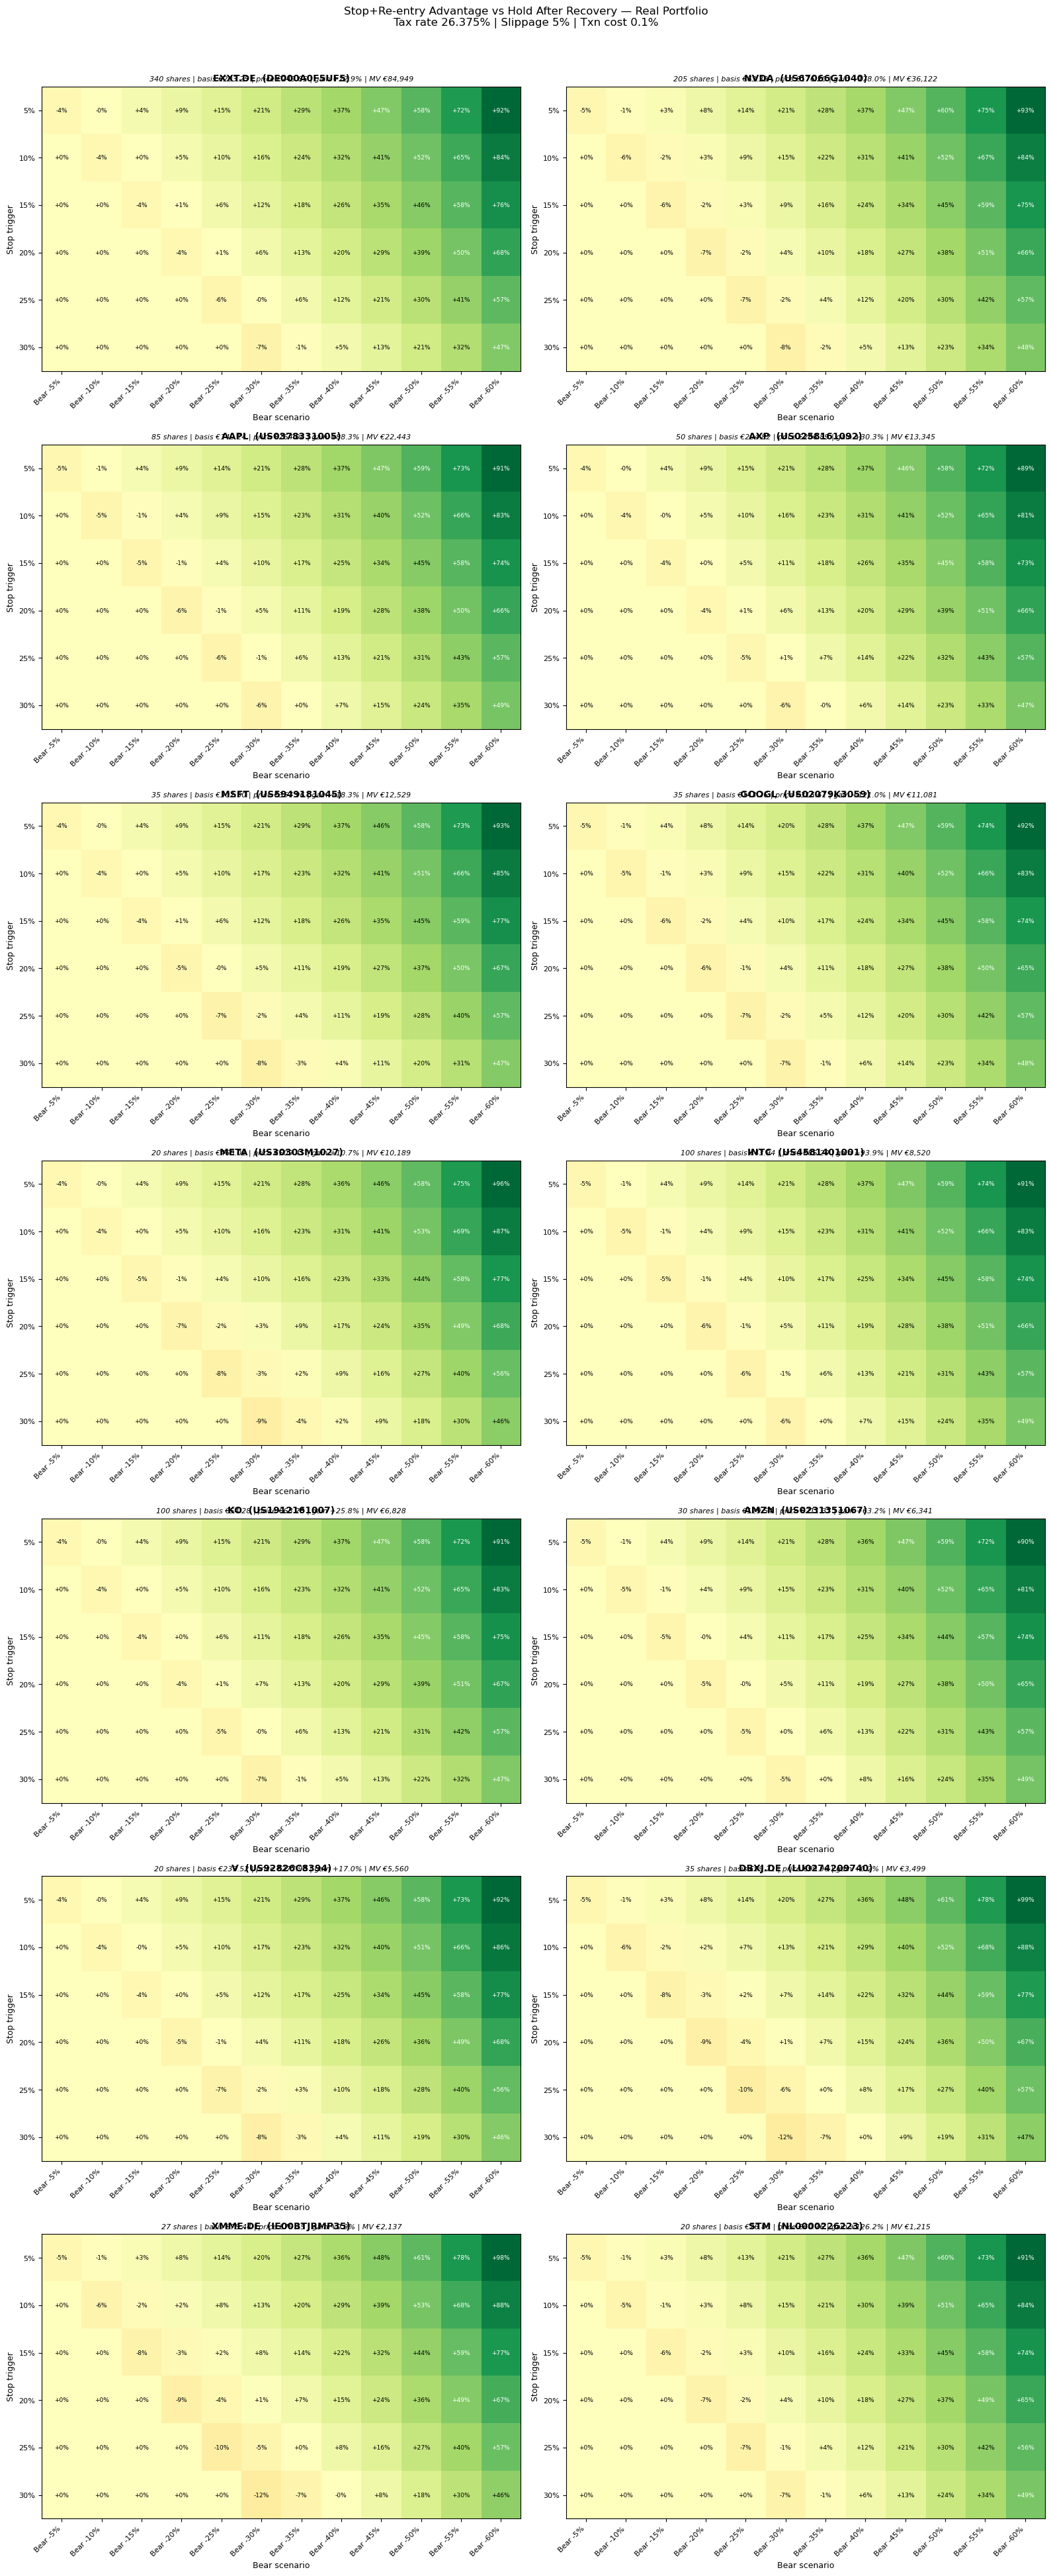

In [11]:
def _advantage_heatmap(ax, comparison_df, bear_case_order, title, subtitle):
    """Draw one stop-reentry advantage heatmap on *ax*."""
    hm = comparison_df.pivot_table(
        index="stop_loss_drop",
        columns="bear_case",
        values="stop_reentry_advantage_vs_hold_after_recovery_pct",
        aggfunc="first",
    ).reindex(columns=bear_case_order)

    max_abs = max(np.nanmax(np.abs(hm.values)), 0.01)
    im = ax.imshow(hm.values, cmap="RdYlGn", vmin=-max_abs, vmax=max_abs, aspect="auto")

    # Annotate cells
    for i in range(hm.shape[0]):
        for j in range(hm.shape[1]):
            val = hm.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:+.0%}", ha="center", va="center", fontsize=6.5,
                        color="black" if abs(val) < 0.5 * max_abs else "white")

    ax.set_xticks(range(len(hm.columns)))
    ax.set_xticklabels(hm.columns, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(hm.index)))
    ax.set_yticklabels([f"{v:.0%}" for v in hm.index], fontsize=8)
    ax.set_xlabel("Bear scenario", fontsize=9)
    ax.set_ylabel("Stop trigger", fontsize=9)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.text(0.5, 1.02, subtitle, transform=ax.transAxes, ha="center", fontsize=8, style="italic")
    return im


# Sort positions by market value descending
ordered_isins = (
    pd.Series({isin: r["shares"] * r["price"] for isin, r in results.items()})
    .sort_values(ascending=False)
    .index.tolist()
)

n = len(ordered_isins)
ncols = 2
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5.5 * nrows))
axes_flat = axes.flatten() if n > 1 else [axes]

for idx, isin in enumerate(ordered_isins):
    r   = results[isin]
    ax  = axes_flat[idx]
    unr = (r["price"] - r["basis"]) / r["basis"]
    title    = f"{r['ticker']}  ({isin})"
    subtitle = (
        f"{r['shares']:,.0f} shares | basis €{r['basis']:,.2f} | "
        f"price €{r['price']:,.2f} | gain {unr:+.1%} | "
        f"MV €{r['shares']*r['price']:,.0f}"
    )
    _advantage_heatmap(ax, r["comparison"], bear_case_order, title, subtitle)

# Hide any unused axes
for idx in range(len(ordered_isins), len(axes_flat)):
    axes_flat[idx].set_visible(False)

fig.suptitle(
    "Stop+Re-entry Advantage vs Hold After Recovery — Real Portfolio\n"
    f"Tax rate {CAPITAL_GAINS_TAX_RATE:.3%} | Slippage {REENTRY_SLIPPAGE:.0%} | "
    f"Txn cost {TRANSACTION_COST_RATE:.1%}",
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.show()

## Step 8 — Best stop per bear case (portfolio view)

For each position and each bear scenario: what is the best-available stop level
and the resulting advantage?  Answers: *"if the market falls 20%, which position
should I have had a stop on, and where?"*

In [12]:
best_rows = []
for isin, r in results.items():
    cmp = r["comparison"]
    for bear_case in bear_case_order:
        slice_df = cmp[(cmp["bear_case"] == bear_case) & cmp["stop_triggers"]]
        if slice_df.empty:
            continue
        best = slice_df.loc[
            slice_df["stop_reentry_advantage_vs_hold_after_recovery"].idxmax()
        ]
        best_rows.append({
            "ticker":    r["ticker"],
            "isin":      isin,
            "bear_case": bear_case,
            "best_stop": best["stop_loss_drop"],
            "advantage_eur": best["stop_reentry_advantage_vs_hold_after_recovery"],
            "advantage_pct": best["stop_reentry_advantage_vs_hold_after_recovery_pct"],
        })

best_df = pd.DataFrame(best_rows)

# Pivot: rows = ticker, columns = bear case
pivot_adv = best_df.pivot_table(
    index="ticker", columns="bear_case",
    values="advantage_eur", aggfunc="first"
).reindex(columns=bear_case_order)

# Sort by the -30% bear scenario
SORT_COL = "Bear -30%"
if SORT_COL in pivot_adv.columns:
    pivot_adv = pivot_adv.sort_values(SORT_COL, ascending=False)

pivot_adv.style \
    .format("€{:+,.0f}", na_rep="—") \
    .background_gradient(cmap="RdYlGn", axis=None)

bear_case,Bear -5%,Bear -10%,Bear -15%,Bear -20%,Bear -25%,Bear -30%,Bear -35%,Bear -40%,Bear -45%,Bear -50%,Bear -55%,Bear -60%
ticker,,,,,,,,,,,,
EXXT.DE,"€-3,388",€-41,"€+3,633","€+7,792","€+12,385","€+17,464","€+23,050","€+29,086","€+35,599","€+42,522","€+49,982","€+59,084"
NVDA,"€-1,586",€-321,"€+1,028","€+2,557","€+4,296","€+6,242","€+8,378","€+10,679","€+13,238","€+15,967","€+18,885","€+22,021"
AAPL,€-952,€-130,€+739,"€+1,741","€+2,884","€+4,114","€+5,523","€+7,046","€+8,657","€+10,387","€+12,259","€+14,272"
AXP,€-537,€-28,€+541,"€+1,175","€+1,908","€+2,694","€+3,514","€+4,482","€+5,459","€+6,559","€+7,751","€+9,017"
MSFT,€-499,€-1,€+546,"€+1,150","€+1,797","€+2,550","€+3,421","€+4,320","€+5,225","€+6,296","€+7,493","€+8,821"
META,€-411,€-15,€+412,€+956,"€+1,474","€+2,119","€+2,798","€+3,495","€+4,322","€+5,213","€+6,268","€+7,402"
GOOGL,€-483,€-82,€+347,€+833,"€+1,364","€+1,932","€+2,596","€+3,362","€+4,143","€+4,999","€+5,910","€+6,921"
INTC,€-363,€-51,€+281,€+663,"€+1,082","€+1,563","€+2,090","€+2,655","€+3,271","€+3,925","€+4,644","€+5,400"
KO,€-275,€-5,€+284,€+621,€+988,"€+1,392","€+1,829","€+2,326","€+2,845","€+3,391","€+4,001","€+4,698"


## Step 9 — Optimal stop level by position (heatmap)

Rows = positions (sorted by MV), columns = bear scenarios.
Cell value = the **best stop trigger** (% drop) for that position × scenario combination.
An empty cell means no stop would trigger in that scenario.

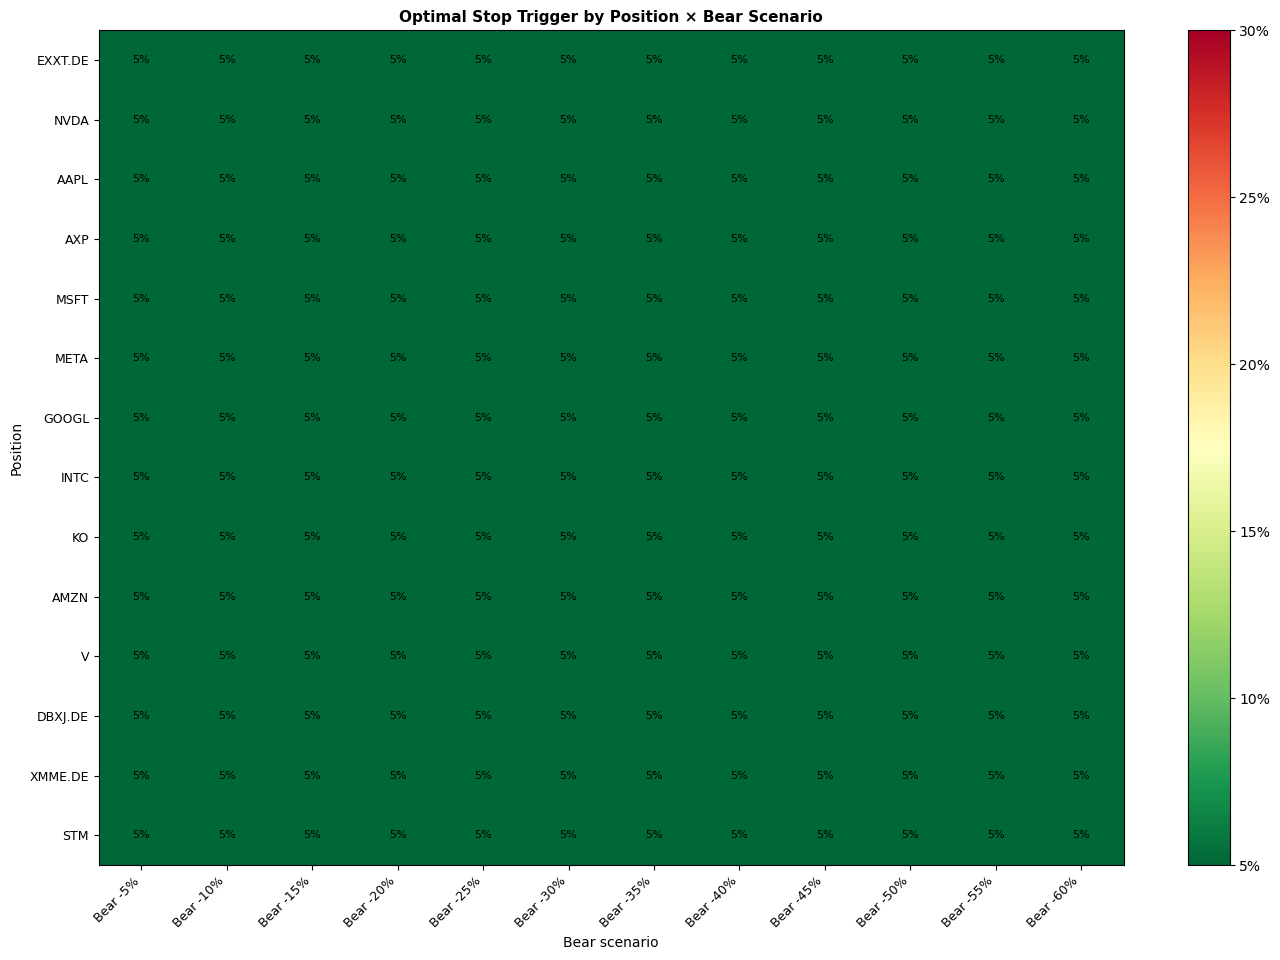

In [13]:
pivot_stop = best_df.pivot_table(
    index="ticker", columns="bear_case",
    values="best_stop", aggfunc="first"
).reindex(columns=bear_case_order)

# Keep same row order as pivot_adv
pivot_stop = pivot_stop.reindex(index=pivot_adv.index)

fig, ax = plt.subplots(figsize=(14, 0.55 * len(pivot_stop) + 2))
vals = pivot_stop.values.astype(float)  # NaN for missing
im = ax.imshow(vals, cmap="RdYlGn_r", vmin=0.05, vmax=0.30, aspect="auto")

for i in range(vals.shape[0]):
    for j in range(vals.shape[1]):
        v = vals[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=8)

ax.set_xticks(range(len(pivot_stop.columns)))
ax.set_xticklabels(pivot_stop.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(pivot_stop.index)))
ax.set_yticklabels(pivot_stop.index, fontsize=9)
ax.set_title("Optimal Stop Trigger by Position × Bear Scenario", fontsize=11, fontweight="bold")
ax.set_xlabel("Bear scenario")
ax.set_ylabel("Position")
cbar = fig.colorbar(im, ax=ax, ticks=[0.05, 0.10, 0.15, 0.20, 0.25, 0.30])
cbar.ax.set_yticklabels(["5%", "10%", "15%", "20%", "25%", "30%"])
plt.tight_layout()
plt.show()